In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage import data


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

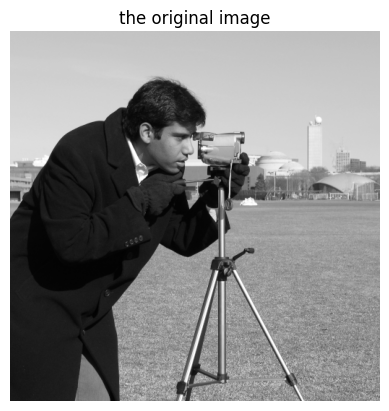

In [2]:
image = data.camera()
plt.imshow(image,cmap='gray')
plt.title("the original image" )
plt.axis('off')

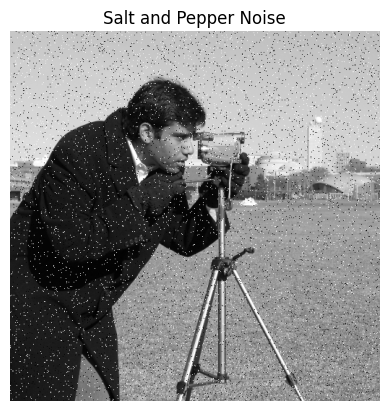

In [3]:
def add_salt_pepper_noise(image, prob=0.02):
    noisy = image.copy()
    
    # Salt (white pixels)
    salt = np.random.rand(*image.shape) < (prob)
    noisy[salt] = 255

    # Pepper (black pixels)
    pepper = np.random.rand(*image.shape) < (prob)
    noisy[pepper] = 0

    return noisy
noisy_img = add_salt_pepper_noise(image)
plt.imshow(noisy_img, cmap='gray')
plt.title("Salt and Pepper Noise")
plt.axis("off")
plt.show()  

In [4]:
sobel_x = cv2.Sobel(noisy_img, cv2.CV_64F, 1, 0,ksize=3)
sobel_y = cv2.Sobel(noisy_img, cv2.CV_64F, 0, 1,ksize=3)

sobel_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)

# Threshold
_, sobel_binary = cv2.threshold(sobel_magnitude, 50, 255, cv2.THRESH_BINARY)#if pixel > 50 → 255 (edge) else → 0 (background)


THRESH_BINARY is a type of image thresholding in OpenCV.

It means:

Convert a grayscale image into a black-and-white image based on a threshold value.

How it works:

For each pixel:

If pixel value > threshold → set it to maximum value (usually 255 = white)
If pixel value ≤ threshold → set it to 0 (black)

In [41]:
kernel_x = np.array([[-1,-1,-1],[0,0,0],[1,1,1]])
kernel_y = np.array([[-1,0,1],[-1,0,1],[-1,0,1]])

prewitt_x = ndimage.convolve(noisy_img, kernel_x)#n_dimenstional imaege convolution with the kernel
prewitt_y = ndimage.convolve(noisy_img, kernel_y)#n_dimenstional imaege convolution with the kernel

prewitt_mag = np.sqrt(prewitt_x**2 + prewitt_y**2)

# Threshold
_, prewitt_binary = cv2.threshold( prewitt_mag.astype(np.float32), 50, 255, cv2.THRESH_BINARY)


In [40]:
laplacian = cv2.Laplacian(noisy_img, cv2.CV_64F)#It allows the output to contain both positive and negative values.

In [42]:
def zero_crossing(img):
    padded_img = np.pad(img, pad_width=1, mode='constant', constant_values=0)
    rows, cols = img.shape
    result = np.zeros((rows, cols), dtype=np.uint8)

    def sign(val):
        return -1 if val < 0 else 1  # zero counts as positive

    for i in range(rows):
        for j in range(cols):
            pi, pj = i + 1, j + 1

            horizontal_neighbour1  = padded_img[pi,   pj-1]
            horizontal_neighbour2   = padded_img[pi,   pj+1]
            vertical_neighbour1   = padded_img[pi-1, pj  ]
            vertical_neighbour2   = padded_img[pi+1, pj  ]
            main_diagonal1 = padded_img[pi-1, pj-1]
            main_diagonal2 = padded_img[pi+1, pj+1]
            anti_diagonal1 = padded_img[pi-1, pj+1]
            anti_diagonal2 = padded_img[pi+1, pj-1]

            if (sign(horizontal_neighbour1)   != sign(horizontal_neighbour2)   or
                sign(vertical_neighbour1)   != sign(vertical_neighbour2)   or
                sign(main_diagonal1) != sign(main_diagonal2) or
                sign(anti_diagonal1) != sign(anti_diagonal2)):

                result[i, j] = 255

    return result


In [43]:
laplacian_zc = zero_crossing(laplacian)


In [44]:
log_filter = np.array([[0,0,-1,0,0],[0,-1,-2,-1,0],[-1,-2,16,-2,-1],[0,-1,-2,-1,0],[0,0,-1,0,0]])
log_result = ndimage.convolve(noisy_img, log_filter)
log_zc = zero_crossing(log_result)

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

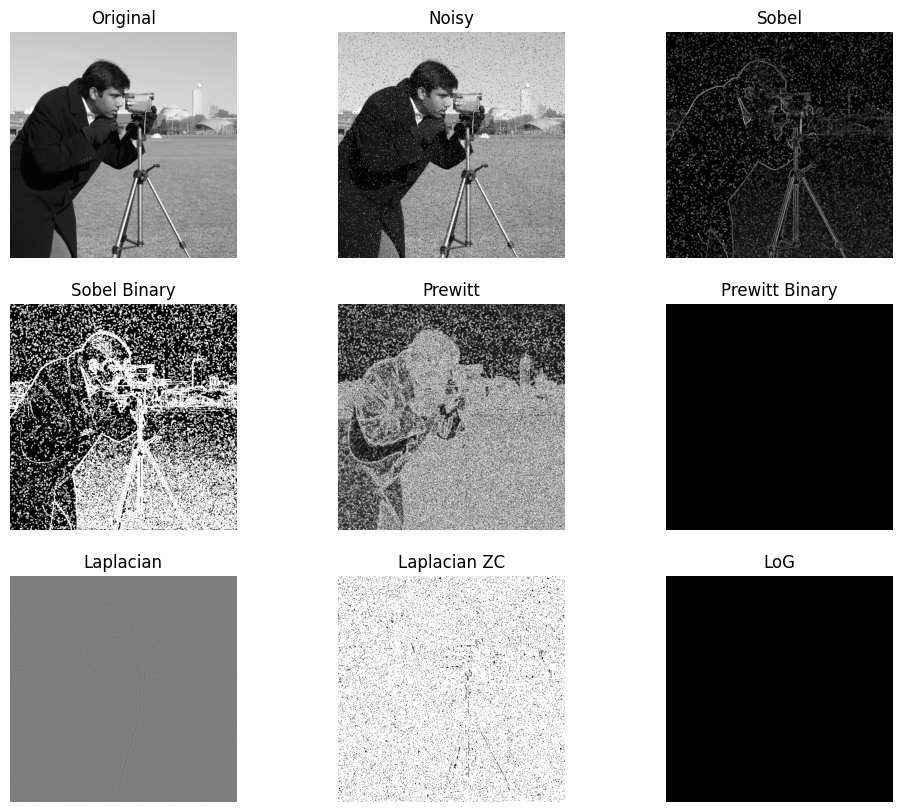

In [46]:
plt.figure(figsize=(12,10))

plt.subplot(3,3,1), plt.imshow(image, cmap='gray'), plt.title('Original')
plt.axis('off')

plt.subplot(3,3,2), plt.imshow(noisy_img, cmap='gray'), plt.title('Noisy')
plt.axis('off')

plt.subplot(3,3,3), plt.imshow(sobel_magnitude, cmap='gray'), plt.title('Sobel')
plt.axis('off')

plt.subplot(3,3,4), plt.imshow(sobel_binary, cmap='gray'), plt.title('Sobel Binary')
plt.axis('off')

plt.subplot(3,3,5), plt.imshow(prewitt_mag, cmap='gray'), plt.title('Prewitt')
plt.axis('off')

plt.subplot(3,3,6), plt.imshow(prewitt_binary, cmap='gray'), plt.title('Prewitt Binary')
plt.axis('off')

plt.subplot(3,3,7), plt.imshow(laplacian, cmap='gray'), plt.title('Laplacian')
plt.axis('off')

plt.subplot(3,3,8), plt.imshow(laplacian_zc, cmap='gray'), plt.title('Laplacian ZC')
plt.axis('off')

plt.subplot(3,3,9), plt.imshow(log_zc, cmap='gray'), plt.title('LoG')
plt.axis('off')


In [47]:
sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0)
sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1)

sobel_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)

# Threshold
_, sobel_binary = cv2.threshold(sobel_magnitude, 50, 255, cv2.THRESH_BINARY)#if pixel > 50 → 255 (edge) else → 0 (background)


In [49]:
kernel_x = np.array([[-1,-1,-1],[0,0,0],[1,1,1]])
kernel_y = np.array([[-1,0,1],[-1,0,1],[-1,0,1]])

prewitt_x = ndimage.convolve(image, kernel_x)#n_dimenstional imaege convolution with the kernel
prewitt_y = ndimage.convolve(image, kernel_y)#n_dimenstional imaege convolution with the kernel

prewitt_mag = np.sqrt(prewitt_x**2 + prewitt_y**2)

# Threshold
_, prewitt_binary = cv2.threshold( prewitt_mag.astype(np.float32), 50, 255, cv2.THRESH_BINARY)


In [50]:
laplacian = cv2.Laplacian(image, cv2.CV_64F)#It allows the output to contain both positive and negative values.

In [51]:
def zero_crossing(img):
    padded_img = np.pad(img, pad_width=1, mode='constant', constant_values=0)
    rows, cols = img.shape
    result = np.zeros((rows, cols), dtype=np.uint8)

    def sign(val):
        return -1 if val < 0 else 1  # zero counts as positive

    for i in range(rows):
        for j in range(cols):
            pi, pj = i + 1, j + 1

            horizontal_neighbour1  = padded_img[pi,   pj-1]
            horizontal_neighbour2   = padded_img[pi,   pj+1]
            vertical_neighbour1   = padded_img[pi-1, pj  ]
            vertical_neighbour2   = padded_img[pi+1, pj  ]
            main_diagonal1 = padded_img[pi-1, pj-1]
            main_diagonal2 = padded_img[pi+1, pj+1]
            anti_diagonal1 = padded_img[pi-1, pj+1]
            anti_diagonal2 = padded_img[pi+1, pj-1]

            if (sign(horizontal_neighbour1)   != sign(horizontal_neighbour2)   or
                sign(vertical_neighbour1)   != sign(vertical_neighbour2)   or
                sign(main_diagonal1) != sign(main_diagonal2) or
                sign(anti_diagonal1) != sign(anti_diagonal2)):

                result[i, j] = 255

    return result


In [52]:
laplacian_zc = zero_crossing(laplacian)


In [53]:
log_filter = np.array([[0,0,-1,0,0],[0,-1,-2,-1,0],[-1,-2,16,-2,-1],[0,-1,-2,-1,0],[0,0,-1,0,0]])
log_result = ndimage.convolve(image, log_filter)
log_zc = zero_crossing(log_result)

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

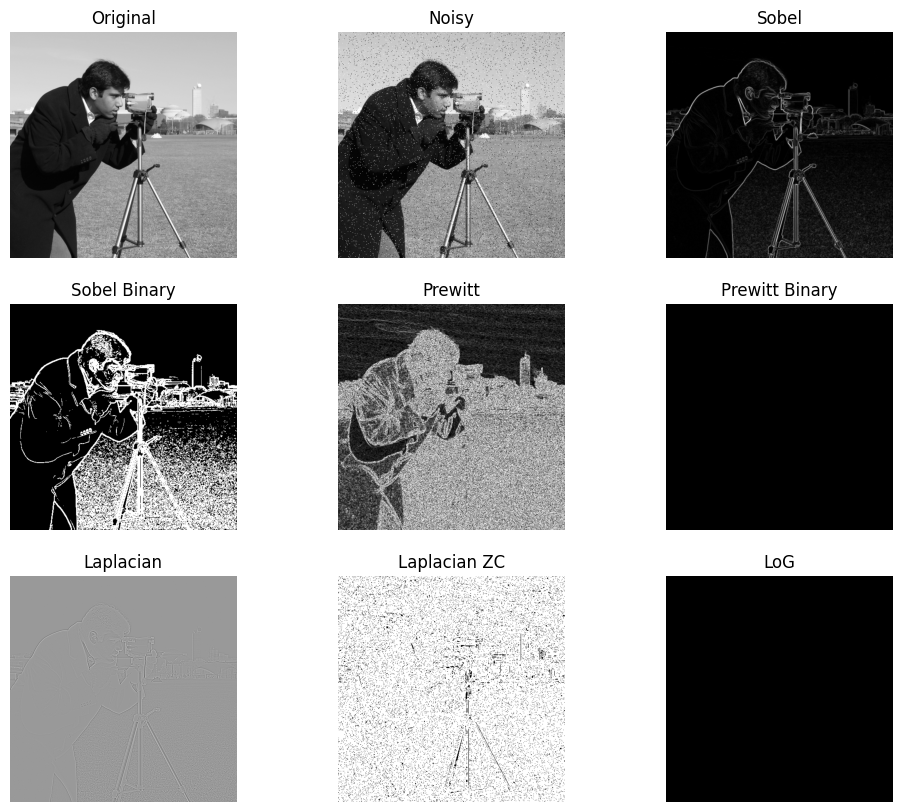

In [54]:
plt.figure(figsize=(12,10))

plt.subplot(3,3,1), plt.imshow(image, cmap='gray'), plt.title('Original')
plt.axis('off')

plt.subplot(3,3,2), plt.imshow(noisy_img, cmap='gray'), plt.title('Noisy')
plt.axis('off')

plt.subplot(3,3,3), plt.imshow(sobel_magnitude, cmap='gray'), plt.title('Sobel')
plt.axis('off')

plt.subplot(3,3,4), plt.imshow(sobel_binary, cmap='gray'), plt.title('Sobel Binary')
plt.axis('off')

plt.subplot(3,3,5), plt.imshow(prewitt_mag, cmap='gray'), plt.title('Prewitt')
plt.axis('off')

plt.subplot(3,3,6), plt.imshow(prewitt_binary, cmap='gray'), plt.title('Prewitt Binary')
plt.axis('off')

plt.subplot(3,3,7), plt.imshow(laplacian, cmap='gray'), plt.title('Laplacian')
plt.axis('off')

plt.subplot(3,3,8), plt.imshow(laplacian_zc, cmap='gray'), plt.title('Laplacian ZC')
plt.axis('off')

plt.subplot(3,3,9), plt.imshow(log_zc, cmap='gray'), plt.title('LoG')
plt.axis('off')
